# EGX360 — THE DEEP QUANT MODEL
### Enhancing Down-Trend Detection & Bias Control in the Egyptian Stock Exchange

## 1. Environment Setup & Initialization

In [7]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

import optuna
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

import tensorflow as tf

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"✅ GPU found by TF: {gpu_devices}")
else:
    print("⚠️ No GPU detected by TF. Running ML on CPU (Multicore Mode).")

⚠️ No GPU detected by TF. Running ML on CPU (Multicore Mode).


## 2. Data Loading & Merging
We begin by loading the preprocessed EGX30 daily data. Financial time series data is notoriously noisy. Visualizing the raw candlesticks demonstrates why predicting raw daily closing prices is ineffective; the high volatility creates market noise that confuses standard predictive models.

In [8]:
print("\nLoading Final Dataset (EGX + USD + Gold + Interest)")
# Load Egx30
current_dir = os.getcwd()
file_path = os.path.join(current_dir, "data", "EGX30_Final_v9.csv")
df = pd.read_csv(file_path)

df['timestamp'] = pd.to_datetime(df['timestamp']).dt.tz_localize(None).dt.normalize()
df.set_index('timestamp', inplace=True)
df.sort_index(inplace=True)

ir_path = os.path.join(current_dir, "data", "cbe_interest_rate.csv")
if os.path.exists(ir_path):
    ir_df = pd.read_csv(ir_path)
    ir_df['Date'] = pd.to_datetime(ir_df['Date']).dt.normalize()
    ir_df.set_index('Date', inplace=True)
    
    df = df.join(ir_df, how='left')
    df['Interest_Rate'] = df['Interest_Rate'].ffill().bfill()
    df['IR_Change'] = df['Interest_Rate'].diff().fillna(0)
    print("✅ Interest Rates Merged.")

df.dropna(inplace=True)
print(f"📊 Base Data Shape: {df.shape}")


Loading Final Dataset (EGX + USD + Gold + Interest)
✅ Interest Rates Merged.
📊 Base Data Shape: (6911, 16)


# 3. Macroeconomic Visualization

In [9]:
fig_macro = make_subplots(rows=3, cols=1, shared_xaxes=True, 
                          vertical_spacing=0.05,
                          subplot_titles=('EGX30 Close Price', 'USD/EGP Exchange Rate', 'Gold Price (EGP)'))

fig_macro.add_trace(go.Scatter(x=df.index, y=df['close'], mode='lines', name='EGX30', line=dict(color='black')), row=1, col=1)
fig_macro.add_trace(go.Scatter(x=df.index, y=df['usd_egp_rate'], mode='lines', name='USD/EGP', line=dict(color='green')), row=2, col=1)
fig_macro.add_trace(go.Scatter(x=df.index, y=df['gold_egp'], mode='lines', name='Gold (EGP)', line=dict(color='goldenrod')), row=3, col=1)

fig_macro.update_layout(height=800, title_text="Macroeconomic Trends in Egypt", template='plotly_white', hovermode='x unified')
fig_macro.show()

# 4. Statistical Analysis & Market Noise

In [10]:
# # returns = df['log_ret'].dropna()

# fig, axes = plt.subplots(3, 1, figsize=(12, 14))
# fig.tight_layout(pad=6.0)

# # 4.1 Fat Tails
# sns.histplot(returns, bins=100, kde=True, stat="density", ax=axes[0], color='blue', alpha=0.5, label='Actual EGX Returns')
# mu, std = stats.norm.fit(returns)
# xmin, xmax = axes[0].get_xlim()
# x = np.linspace(xmin, xmax, 100)
# axes[0].plot(x, stats.norm.pdf(x, mu, std), 'k', linewidth=2, linestyle='dashed', label='Normal Distribution')
# axes[0].set_title("1. Return Distribution: The 'Fat Tails' Problem", fontsize=12, fontweight='bold')
# axes[0].legend()

# axes[1].plot(returns.index, np.abs(returns), color='red', alpha=0.7, linewidth=0.8)
# axes[1].set_title("2. Volatility Clustering: Crises and Panics Group Together", fontsize=12, fontweight='bold')
# axes[1].set_ylabel("Absolute Daily Return")

# # 4.3 Autocorrelation (ACF)
# plot_acf(returns, lags=40, ax=axes[2], alpha=0.05, color='green')
# axes[2].set_title("3. Autocorrelation (ACF): Proof of Market Noise", fontsize=12, fontweight='bold')
# axes[2].set_xlabel("Lag (Days)")
# plt.show()

# 5. Drawdown & Outliers (Black Swans)

In [11]:
# # Drawdown Calculation
# cumulative_returns = (1 + returns).cumprod()
# running_max = cumulative_returns.cummax()
# drawdown = (cumulative_returns - running_max) / running_max

# fig_dd = go.Figure()
# fig_dd.add_trace(go.Scatter(x=drawdown.index, y=drawdown * 100, 
#                             mode='lines', name='Drawdown %', 
#                             line=dict(color='darkred', width=1.5),
#                             fill='tozeroy', fillcolor='rgba(139, 0, 0, 0.3)'))
# fig_dd.update_layout(title='Market Pain Index: Historical Drawdowns', yaxis_title='Drawdown (%)', height=400, template='plotly_white')
# fig_dd.show()

# # Outliers (Z-Score > 3)
# z_scores = np.abs(stats.zscore(returns))
# outliers = returns[z_scores > 3]

# fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# sns.boxplot(x=returns, ax=axes[0], color='lightgray', flierprops=dict(markerfacecolor='red', marker='o', markersize=5))
# axes[0].set_title("1. Distribution Boxplot", fontsize=14, fontweight='bold')

# axes[1].plot(returns.index, returns, color='lightblue', alpha=0.5, label='Normal Days')
# axes[1].scatter(outliers.index, outliers, color='red', s=20, label=f'Extreme Events: {len(outliers)} Days')
# axes[1].set_title("2. Historical Black Swans", fontsize=14, fontweight='bold')
# axes[1].legend()
# plt.tight_layout()
# plt.show()

# 6. Target Definition (Noise Filtration)

In [12]:

# sample_noise_df = df.tail(250)
# fig_smooth = go.Figure()
# fig_smooth.add_trace(go.Scatter(x=sample_noise_df.index, y=sample_noise_df['close'], mode='lines', name='Noisy Raw Price', line=dict(color='lightgray', width=1.5)))
# fig_smooth.add_trace(go.Scatter(x=sample_noise_df.index, y=sample_noise_df['EMA_10'], mode='lines', name='Target: EMA 10 (Clean Signal)', line=dict(color='blue', width=3)))
# fig_smooth.update_layout(title='Noise Filtration: EMA vs Raw Price', yaxis_title='Price (EGP)', height=500, template='plotly_white')
# fig_smooth.show()

## 3. Advanced Feature Engineering (The Quant Indicators)
To make the data machine-readable, we engineer quantitative features. We translate raw price action into mathematical signals representing Trend, Momentum, and Volatility.

### A. Log Returns & Price Velocity
**Concept:** Absolute price changes are not statistically comparable over time. Logarithmic returns stabilize the variance. **Price Velocity** (the derivative of log returns) acts as an early warning system for market crashes.

**Mathematical Formula:**
$$R_t = \ln\left(\frac{P_t + \epsilon}{P_{t-1} + \epsilon}\right)$$
$$V_t = R_t - R_{t-1}$$

In [13]:
print("\n⚙️ Engineering Quant Features...")

df['log_ret'] = np.log((df['close'] + 1e-6) / (df['close'].shift(1) + 1e-6))
df['price_velocity'] = df['log_ret'].diff()

if 'close_usd' in df.columns:
    df['log_ret_usd'] = np.log((df['close_usd'] + 1e-6) / (df['close_usd'].shift(1) + 1e-6))
    df['price_velocity_usd'] = df['log_ret_usd'].diff()
    df['log_ret_usd_lag1'] = df['log_ret_usd'].shift(1)

df['Volume_SMA_50'] = df['volume'].rolling(window=50).mean()
df['RVOL_50'] = (df['volume'] / (df['Volume_SMA_50'] + 1e-9)).clip(upper=5.0)

df['day_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
df['day_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)

for period in [9, 10, 20, 21, 50]:
    ema_col = f'EMA_{period}'
    df[ema_col] = df['close'].ewm(span=period).mean()
    df[f'dist_EMA_{period}'] = (df['close'] - df[ema_col]) / (df[ema_col] + 1e-9)

df['below_EMA9'] = (df['close'] < df['EMA_9']).astype(int)
df['EMA_Spread'] = (df['EMA_10'] - df['EMA_20']) / (df['EMA_20'] + 1e-9)
df['EMA_Cross_Signal'] = (df['EMA_10'] > df['EMA_20']).astype(int)

delta = df['close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain/(loss + 1e-9)))
df['RSI_diff'] = df['RSI'].diff()

macd = df['close'].ewm(span=12).mean() - df['close'].ewm(span=26).mean()
df['MACD_Hist'] = macd - macd.ewm(span=9).mean()

tr = pd.concat([df['high'] - df['low'], 
                np.abs(df['high'] - df['close'].shift()), 
                np.abs(df['low'] - df['close'].shift())], axis=1).max(axis=1)
df['ATR_pct'] = tr.rolling(14).mean() / (df['close'] + 1e-9)

low_14 = df['low'].rolling(14).min()
high_14 = df['high'].rolling(14).max()
df['Stoch_K'] = 100 * ((df['close'] - low_14) / (high_14 - low_14 + 1e-9))

ma20 = df['close'].rolling(20).mean()
std20 = df['close'].rolling(20).std()
df['BB_Width'] = (std20 * 4) / (ma20 + 1e-9)

df['log_ret_lag1'] = df['log_ret'].shift(1)
df['RSI_lag1'] = df['RSI'].shift(1)

# Target: EMA 10 Direction
df['Target'] = (df['close'].shift(-1) > df['EMA_10']).astype(int)


⚙️ Engineering Quant Features...


In [14]:
print("🛠️ Fixing Lagging Effects & Shock Sensors...")

if 'price_velocity_usd' in df.columns:
    df['USD_Shock'] = (df['price_velocity_usd'] > 0.02).astype(int)

if 'IR_Change' in df.columns:
    df['Rate_Hike_Flag'] = (df['IR_Change'] > 0).astype(int)
    df['Rate_Drop_Flag'] = (df['IR_Change'] < 0).astype(int)

if 'RSI' in df.columns and 'Stoch_K' in df.columns:
    df['Composite_Momentum'] = (df['RSI'] + df['Stoch_K']) / 2
    df.drop(columns=['Stoch_K'], inplace=True, errors='ignore')

df.dropna(inplace=True)
print(f"✅ Data cleaned! Total Features: {len(df.columns)}")

🛠️ Fixing Lagging Effects & Shock Sensors...
✅ Data cleaned! Total Features: 48


In [15]:
print("\n" + "="*50)
print("🧠 INITIATING MACHINE LEARNING PIPELINE")
print("="*50)

# Protecting essential columns from training
features_to_drop = ['Target', 'timestamp', 'Date', 'close', 'open', 'high', 'low', 'volume', 'close_usd', 'usd_egp_rate', 'gold_egp']
final_features = [col for col in df.columns if col not in features_to_drop]

X = df[final_features].values
y = df['Target'].values

split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- XGBoost Tuning ---
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'random_state': 42,
        'tree_method': 'hist',
        'n_jobs': -1 
    }
    model = xgb.XGBClassifier(**params)
    return cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()

print("🚀 Starting Optuna Tuning for XGBoost...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=30) 
best_xgb_params = study_xgb.best_params

# --- LightGBM Tuning ---
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1
    }
    model = lgb.LGBMClassifier(**params)
    return cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()

print("🚀 Starting Optuna Tuning for LightGBM...")
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=30)
best_lgb_params = study_lgb.best_params

# --- Stacking ---
print("⚙️ Training Final Stacked Model...")
best_xgb = xgb.XGBClassifier(**best_xgb_params, random_state=42, tree_method='hist', n_jobs=-1)
best_lgb = lgb.LGBMClassifier(**best_lgb_params, random_state=42, verbose=-1, n_jobs=-1)

base_models = [('xgb', best_xgb), ('lgbm', best_lgb)]
final_logic = LogisticRegression(C=1.0) 
stack_model = StackingClassifier(estimators=base_models, final_estimator=final_logic, cv=5)
stack_model.fit(X_train_scaled, y_train)


🧠 INITIATING MACHINE LEARNING PIPELINE
🚀 Starting Optuna Tuning for XGBoost...


[W 2026-05-12 02:41:58,180] Trial 0 failed with parameters: {'n_estimators': 997, 'max_depth': 5, 'learning_rate': 0.054105957469219, 'subsample': 0.8337732743104251, 'colsample_bytree': 0.7911979383426626, 'gamma': 4.1306542407901405} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/heiba/.local/lib/python3.11/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_15421/3629000460.py", line 34, in objective_xgb
    return cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib64/python3.11/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib64/python3.11/site-packages/sklearn/model_selection/_val

KeyboardInterrupt: 

In [ ]:
# ------------------------------------------------------------
# 7. Final Evaluation & Strategy Visualization
# ------------------------------------------------------------
y_pred = stack_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred) * 100

print(f"\n🏆 DEEP QUANT ACCURACY: {acc:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Down Trend (0)', 'Up Trend (1)']))

# Strategy Visualization
print("\n📈 Generating Strategy Visualization...")
test_dates = pd.Series(df.index[split:]).reset_index(drop=True)
test_close = df['close'].iloc[split:].reset_index(drop=True)
test_ema10 = df['EMA_10'].iloc[split:].reset_index(drop=True)

results_df = pd.DataFrame({'timestamp': test_dates, 'close': test_close, 'EMA_10': test_ema10, 'Predicted_Trend': y_pred})
viz_df = results_df.tail(150)

fig_test = go.Figure()
fig_test.add_trace(go.Scatter(x=viz_df['timestamp'], y=viz_df['close'], mode='lines', name='Close Price', line=dict(color='rgba(128,128,128,0.5)', width=1.5)))
fig_test.add_trace(go.Scatter(x=viz_df['timestamp'], y=viz_df['EMA_10'], mode='lines', name='EMA 10 (Target)', line=dict(color='blue', width=2)))

buy_signals = viz_df[viz_df['Predicted_Trend'] == 1]
sell_signals = viz_df[viz_df['Predicted_Trend'] == 0]
fig_test.add_trace(go.Scatter(x=buy_signals['timestamp'], y=buy_signals['EMA_10'], mode='markers', name='Signal: UP', marker=dict(color='green', symbol='triangle-up', size=12)))
fig_test.add_trace(go.Scatter(x=sell_signals['timestamp'], y=sell_signals['EMA_10'], mode='markers', name='Signal: DOWN', marker=dict(color='red', symbol='triangle-down', size=12)))
fig_test.update_layout(title='EGX360 Live Signals: Predictions vs Actual', yaxis_title='Price (EGP)', template='plotly_white', hovermode='x unified')
fig_test.show()

# ------------------------------------------------------------
# 8. EGX360 API JSON Generator (For Flutter)
# ------------------------------------------------------------
print("\n" + "="*50)
print("📦 PACKAGING DATA FOR SERVER (JSON EXPORT)")
print("="*50)

latest_date = df.index[-1]
last_day_data = df.iloc[-1]

api_response = {
    "date": str(latest_date.date()),
    "technical_indicators": {},
    "macro_economics": {},
    "consensus": {},
    "ml_prediction": {}
}

votes = {'UP': 0, 'DOWN': 0, 'NEUTRAL': 0}

if 'EMA_Cross_Signal' in df.columns:
    val = int(last_day_data['EMA_Cross_Signal'])
    state = "🟢 إيجابي (تقاطع لأعلى)" if val == 1 else "🔴 سلبي (تقاطع لأسفل)"
    if val == 1: votes['UP'] += 1 
    else: votes['DOWN'] += 1
    api_response["technical_indicators"]["ema_cross"] = {"value": val, "status": state}

if 'MACD_Hist' in df.columns:
    val = float(last_day_data['MACD_Hist'])
    state = "🟢 إيجابي (زخم شرائي)" if val > 0 else "🔴 سلبي (زخم بيعي)"
    if val > 0: votes['UP'] += 1 
    else: votes['DOWN'] += 1
    api_response["technical_indicators"]["macd"] = {"value": round(val, 4), "status": state}

if 'Composite_Momentum' in df.columns:
    val = float(last_day_data['Composite_Momentum'])
    if val > 75: state, votes['DOWN'] = "🔴 خطر هبوط (تشبع شراء)", votes['DOWN'] + 1
    elif val < 25: state, votes['UP'] = "🟢 فرصة صعود (تشبع بيع)", votes['UP'] + 1
    else: state, votes['NEUTRAL'] = "⚪ طبيعي (زخم مستقر)", votes['NEUTRAL'] + 1
    api_response["technical_indicators"]["momentum"] = {"value": round(val, 2), "status": state}

if 'IR_Change' in df.columns:
    val = float(last_day_data['IR_Change'])
    if val > 0: state, votes['DOWN'] = "🔴 سلبي (رفع الفائدة)", votes['DOWN'] + 1
    elif val < 0: state, votes['UP'] = "🟢 إيجابي (خفض الفائدة)", votes['UP'] + 1
    else: state, votes['NEUTRAL'] = "⚪ طبيعي (الفائدة ثابتة)", votes['NEUTRAL'] + 1
    api_response["macro_economics"]["interest_rate_change"] = {"value": val, "status": state}

if 'usd_egp_rate' in df.columns and 'USD_Shock' in df.columns:
    usd_rate = float(last_day_data['usd_egp_rate'])
    shock = int(last_day_data['USD_Shock'])
    if shock == 1: state, votes['UP'] = "🟢 إيجابي للأسهم (تحوط بالبورصة)", votes['UP'] + 1
    else: state, votes['NEUTRAL'] = "⚪ طبيعي (استقرار الصرف)", votes['NEUTRAL'] + 1
    api_response["macro_economics"]["usd_egp"] = {"rate": round(usd_rate, 2), "shock_detected": bool(shock), "status": state}

total_votes = sum(votes.values())
if total_votes > 0:
    up_pct = round((votes['UP'] / total_votes) * 100, 1)
    down_pct = round((votes['DOWN'] / total_votes) * 100, 1)
    
    if up_pct > 50: trend = "BULLISH (صاعد)"
    elif down_pct > 50: trend = "BEARISH (هابط)"
    else: trend = "NEUTRAL (محايد)"
    
    api_response["consensus"] = {
        "up_percentage": up_pct,
        "down_percentage": down_pct,
        "overall_trend": trend
    }

latest_features = X_test_scaled[-1].reshape(1, -1)
ml_pred = int(stack_model.predict(latest_features)[0])
ml_prob = float(stack_model.predict_proba(latest_features)[0][1]) * 100

api_response["ml_prediction"] = {
    "signal": "UP (صعود)" if ml_pred == 1 else "DOWN (هبوط)",
    "confidence_percentage": round(ml_prob if ml_pred == 1 else 100 - ml_prob, 2),
    "model_version": "EGX360_Deep_Quant"
}

output_filename = "egx360_daily_signal.json"
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(api_response, f, ensure_ascii=False, indent=4)

print(f"✅ Success! Data perfectly packaged and saved to '{output_filename}'")


🏆 DEEP QUANT ACCURACY: 84.85%

Classification Report:
                precision    recall  f1-score   support

Down Trend (0)       0.80      0.79      0.80       511
  Up Trend (1)       0.88      0.88      0.88       862

      accuracy                           0.85      1373
     macro avg       0.84      0.84      0.84      1373
  weighted avg       0.85      0.85      0.85      1373


📈 Generating Strategy Visualization...



📦 PACKAGING DATA FOR SERVER (JSON EXPORT)
✅ Success! Data perfectly packaged and saved to 'egx360_daily_signal.json'


In [ ]:
import json
import numpy as np

# ------------------------------------------------------------
# 8. EGX360 FULL API JSON Generator (All 35+ Features)
# ------------------------------------------------------------
print("\n" + "="*50)
print("📦 PACKAGING ALL 35+ FEATURES FOR SERVER (FULL JSON)")
print("="*50)

latest_date = df.index[-1]
last_day_data = df.iloc[-1]

# الهيكل الأساسي للرد
api_response = {
    "date": str(latest_date.date()),
    "raw_market_data": {},
    "all_computed_features": {},  # هنا هنرمي الـ 35 مؤشر كلهم أوتوماتيك
    "smart_analysis": {},         # هنا النصوص اللي هتتعرض في تطبيق فلاتر
    "consensus": {},
    "ml_prediction": {}
}

# 1. الأسعار الخام (عشان لو هترسم الشموع في التطبيق)
raw_cols = ['open', 'high', 'low', 'close', 'volume', 'usd_egp_rate', 'gold_egp']
for col in raw_cols:
    if col in df.columns:
        api_response["raw_market_data"][col] = float(last_day_data[col])

# 2. حلقة التكرار السحرية (بتسحب كل الـ 35 Feature وتحطهم في الـ JSON)
# عشان مفيش أي حاجة تقع مننا مهما ضفنا بعد كده
for col in df.columns:
    if col not in raw_cols and col not in ['Target', 'Date', 'timestamp']:
        val = last_day_data[col]
        # معالجة أنواع البيانات عشان الـ JSON ميضربش Error
        if pd.isna(val):
            api_response["all_computed_features"][col] = None
        elif isinstance(val, (np.integer, int)):
            api_response["all_computed_features"][col] = int(val)
        elif isinstance(val, (np.floating, float)):
            api_response["all_computed_features"][col] = round(float(val), 6)
        else:
            api_response["all_computed_features"][col] = str(val)

# 3. التحليل الذكي (اللي هيتعرض للمستخدم في التطبيق كنصوص)
votes = {'UP': 0, 'DOWN': 0, 'NEUTRAL': 0}

if 'EMA_Cross_Signal' in df.columns:
    val = int(last_day_data['EMA_Cross_Signal'])
    state = "🟢 تقاطع لأعلى (صعود)" if val == 1 else "🔴 تقاطع لأسفل (هبوط)"
    if val == 1: votes['UP'] += 1 
    else: votes['DOWN'] += 1
    api_response["smart_analysis"]["ema_cross"] = {"status": state}

if 'MACD_Hist' in df.columns:
    val = float(last_day_data['MACD_Hist'])
    state = "🟢 زخم شرائي" if val > 0 else "🔴 زخم بيعي"
    if val > 0: votes['UP'] += 1 
    else: votes['DOWN'] += 1
    api_response["smart_analysis"]["macd"] = {"status": state}

if 'Composite_Momentum' in df.columns:
    val = float(last_day_data['Composite_Momentum'])
    if val > 75: state, votes['DOWN'] = "🔴 خطر هبوط (تشبع شراء)", votes['DOWN'] + 1
    elif val < 25: state, votes['UP'] = "🟢 فرصة صعود (تشبع بيع)", votes['UP'] + 1
    else: state, votes['NEUTRAL'] = "⚪ طبيعي (زخم مستقر)", votes['NEUTRAL'] + 1
    api_response["smart_analysis"]["momentum"] = {"status": state}

if 'IR_Change' in df.columns:
    val = float(last_day_data['IR_Change'])
    if val > 0: state, votes['DOWN'] = "🔴 سلبي (رفع الفائدة)", votes['DOWN'] + 1
    elif val < 0: state, votes['UP'] = "🟢 إيجابي (خفض الفائدة)", votes['UP'] + 1
    else: state, votes['NEUTRAL'] = "⚪ طبيعي (الفائدة ثابتة)", votes['NEUTRAL'] + 1
    api_response["smart_analysis"]["interest_rate"] = {"status": state}

if 'usd_egp_rate' in df.columns and 'USD_Shock' in df.columns:
    shock = int(last_day_data['USD_Shock'])
    if shock == 1: state, votes['UP'] = "🟢 إيجابي (تحوط بالبورصة لقفزة الدولار)", votes['UP'] + 1
    else: state, votes['NEUTRAL'] = "⚪ طبيعي (استقرار الصرف)", votes['NEUTRAL'] + 1
    api_response["smart_analysis"]["usd_impact"] = {"status": state}

# 4. التصويت النهائي (Consensus)
total_votes = sum(votes.values())
if total_votes > 0:
    up_pct = round((votes['UP'] / total_votes) * 100, 1)
    down_pct = round((votes['DOWN'] / total_votes) * 100, 1)
    
    if up_pct > 50: trend = "BULLISH (صاعد)"
    elif down_pct > 50: trend = "BEARISH (هابط)"
    else: trend = "NEUTRAL (محايد)"
    
    api_response["consensus"] = {
        "up_percentage": up_pct,
        "down_percentage": down_pct,
        "overall_trend": trend
    }

# 5. توقع الذكاء الاصطناعي (ML Prediction)
latest_features = X_test_scaled[-1].reshape(1, -1)
ml_pred = int(stack_model.predict(latest_features)[0])
ml_prob = float(stack_model.predict_proba(latest_features)[0][1]) * 100

api_response["ml_prediction"] = {
    "signal": "UP (صعود)" if ml_pred == 1 else "DOWN (هبوط)",
    "confidence_percentage": round(ml_prob if ml_pred == 1 else 100 - ml_prob, 2),
    "model_version": "EGX360_Deep_Quant_v8.4"
}

# حفظ الملف
output_filename = "egx360_daily_signal.json"
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(api_response, f, ensure_ascii=False, indent=4)

print(f"✅ Success! ALL 35 features packed dynamically into '{output_filename}'")


📦 PACKAGING ALL 35+ FEATURES FOR SERVER (FULL JSON)
✅ Success! ALL 35 features packed dynamically into 'egx360_daily_signal.json'


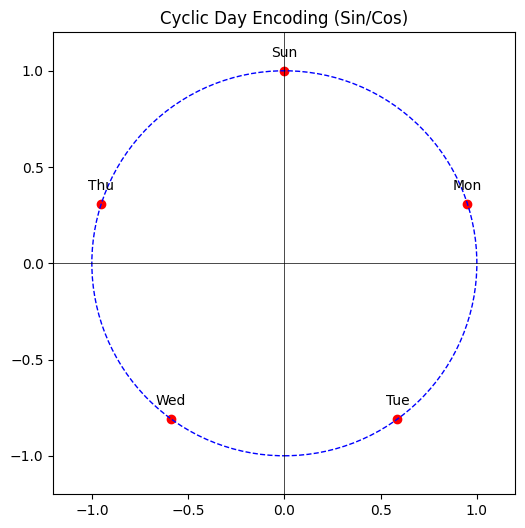

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

days = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu']
angles = np.linspace(0, 2*np.pi, len(days), endpoint=False)
x = np.sin(angles)
y = np.cos(angles)

plt.figure(figsize=(6,6))
plt.scatter(x, y, color='red')
for i, day in enumerate(days):
    plt.annotate(day, (x[i], y[i]), textcoords="offset points", xytext=(0,10), ha='center')

circle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--')
plt.gca().add_artist(circle)
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.title("Cyclic Day Encoding (Sin/Cos)")
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [ ]:
import joblib

# حفظ الموديل
joblib.dump(stack_model, 'egx360_stack_model.pkl')
# حفظ الـ Scaler عشان تستخدمه وقت التوقع
joblib.dump(scaler, 'egx360_scaler.pkl')